# Laboratorio #6 – Transfer Learning y Fine-Tuning
> Antes de entrenar se revisa si existe un archivo guardado de un entrenamiento previo: si existe y su configuración coincide, se carga en lugar de reentrenar**. Ver la sección 3.1.

## 0. Configuración

In [ ]:
import os, time, random, copy, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.models import vgg16, VGG16_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, classification_report)

try:                                   # conteo de parámetros y MACs
    from torchinfo import summary
except ImportError:
    %pip install -q torchinfo
    from torchinfo import summary

SEED = 42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True   # elige los kernels de convolución más rápidos para cada tamaño

# Hardware utilizado (se reporta en el PDF)
print("Device:", device)
print("CPU:", platform.processor(), f"({os.cpu_count()} hilos)")
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0),
          f"({torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB)")
print("PyTorch:", torch.__version__)

Device: cuda
CPU: Intel64 Family 6 Model 191 Stepping 2, GenuineIntel (24 hilos)
GPU: NVIDIA GeForce RTX 4060 Laptop GPU (8.0 GB)
PyTorch: 2.13.0+cu126


## 1. Carga del dataset

In [2]:
# Datasets "crudos" (imágenes PIL) para exploración
train_raw = datasets.CIFAR10(root="data", train=True, download=True)
test_raw  = datasets.CIFAR10(root="data", train=False, download=True)

class_names = train_raw.classes
y_train_all = np.array(train_raw.targets)
y_test = np.array(test_raw.targets)
print(class_names)

100%|██████████| 170M/170M [20:47<00:00, 137kB/s]  


['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 2. Exploración de los datos

### 2.1 Número de observaciones, clases y balance

Observaciones train (original): 50,000
Observaciones test (oficial):   10,000
Número de clases: 10


,clase,train,test
0,airplane,5000,1000
1,automobile,5000,1000
2,bird,5000,1000
3,cat,5000,1000
4,deer,5000,1000
5,dog,5000,1000
6,frog,5000,1000
7,horse,5000,1000
8,ship,5000,1000
9,truck,5000,1000


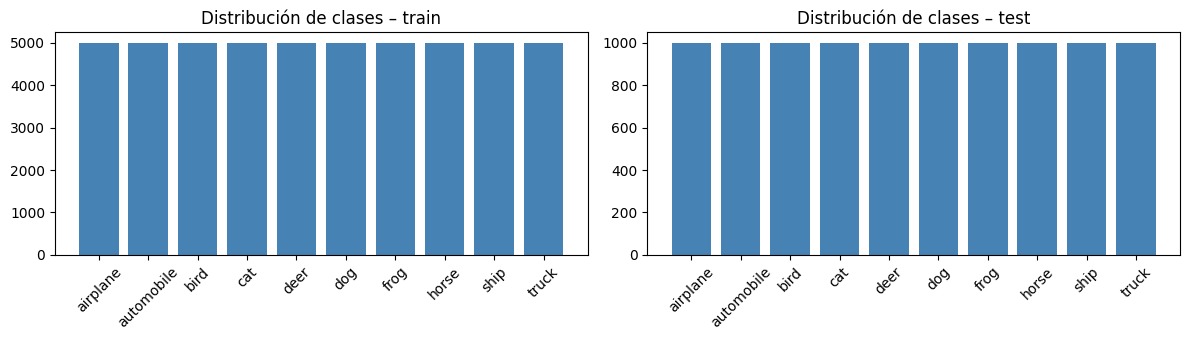

In [3]:
print(f"Observaciones train (original): {len(train_raw):,}")
print(f"Observaciones test (oficial):   {len(test_raw):,}")
print(f"Número de clases: {len(class_names)}")

counts = pd.DataFrame({
    "clase": class_names,
    "train": np.bincount(y_train_all),
    "test": np.bincount(y_test),
})
display(counts)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
for a, col in zip(ax, ["train", "test"]):
    a.bar(counts["clase"], counts[col], color="steelblue")
    a.set_title(f"Distribución de clases – {col}")
    a.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

**Respuesta:** CIFAR-10 tiene 50,000 imágenes de entrenamiento y 10,000 de test, en 10 clases. Las clases están **perfectamente balanceadas** (5,000 por clase en train y 1,000 en test), por lo que accuracy es una métrica razonable, aunque igual se reportan precision, recall y F1 macro.

### 2.2 Resolución, canales y estadísticas por canal

In [4]:
X_train = train_raw.data            # (50000, 32, 32, 3) uint8
print("Shape del arreglo de train:", X_train.shape)
print("Resolución:", X_train.shape[1:3], "| Canales:", X_train.shape[3], "| dtype:", X_train.dtype)

cifar_mean = (X_train / 255.0).mean(axis=(0, 1, 2))
cifar_std  = (X_train / 255.0).std(axis=(0, 1, 2))
imagenet_mean = np.array([0.485, 0.456, 0.406])
imagenet_std  = np.array([0.229, 0.224, 0.225])

stats = pd.DataFrame({
    "CIFAR-10 mean": cifar_mean, "ImageNet mean": imagenet_mean,
    "CIFAR-10 std": cifar_std,   "ImageNet std": imagenet_std,
}, index=["R", "G", "B"]).round(4)
display(stats)

CIFAR_MEAN, CIFAR_STD = tuple(cifar_mean.tolist()), tuple(cifar_std.tolist())
IMAGENET_MEAN, IMAGENET_STD = tuple(imagenet_mean.tolist()), tuple(imagenet_std.tolist())

Shape del arreglo de train: (50000, 32, 32, 3)
Resolución: (32, 32) | Canales: 3 | dtype: uint8


,CIFAR-10 mean,ImageNet mean,CIFAR-10 std,ImageNet std
R,0.4914,0.485,0.2470,0.229
G,0.4822,0.456,0.2435,0.224
B,0.4465,0.406,0.2616,0.225


**Respuesta:** las imágenes son de **32×32 píxeles con 3 canales (RGB)**. Las estadísticas de CIFAR-10 son cercanas a las de ImageNet, pero no idénticas: la media de CIFAR-10 es ligeramente mayor (~0.49, 0.48, 0.45 vs 0.485, 0.456, 0.406) y su desviación estándar también es mayor (~0.25 vs ~0.225). Para la CNN desde cero se normaliza con las estadísticas propias de CIFAR-10. Para VGG-16 se usan las de ImageNet, porque el backbone fue preentrenado con esa distribución de entrada.

### 2.3 Ejemplos por clase

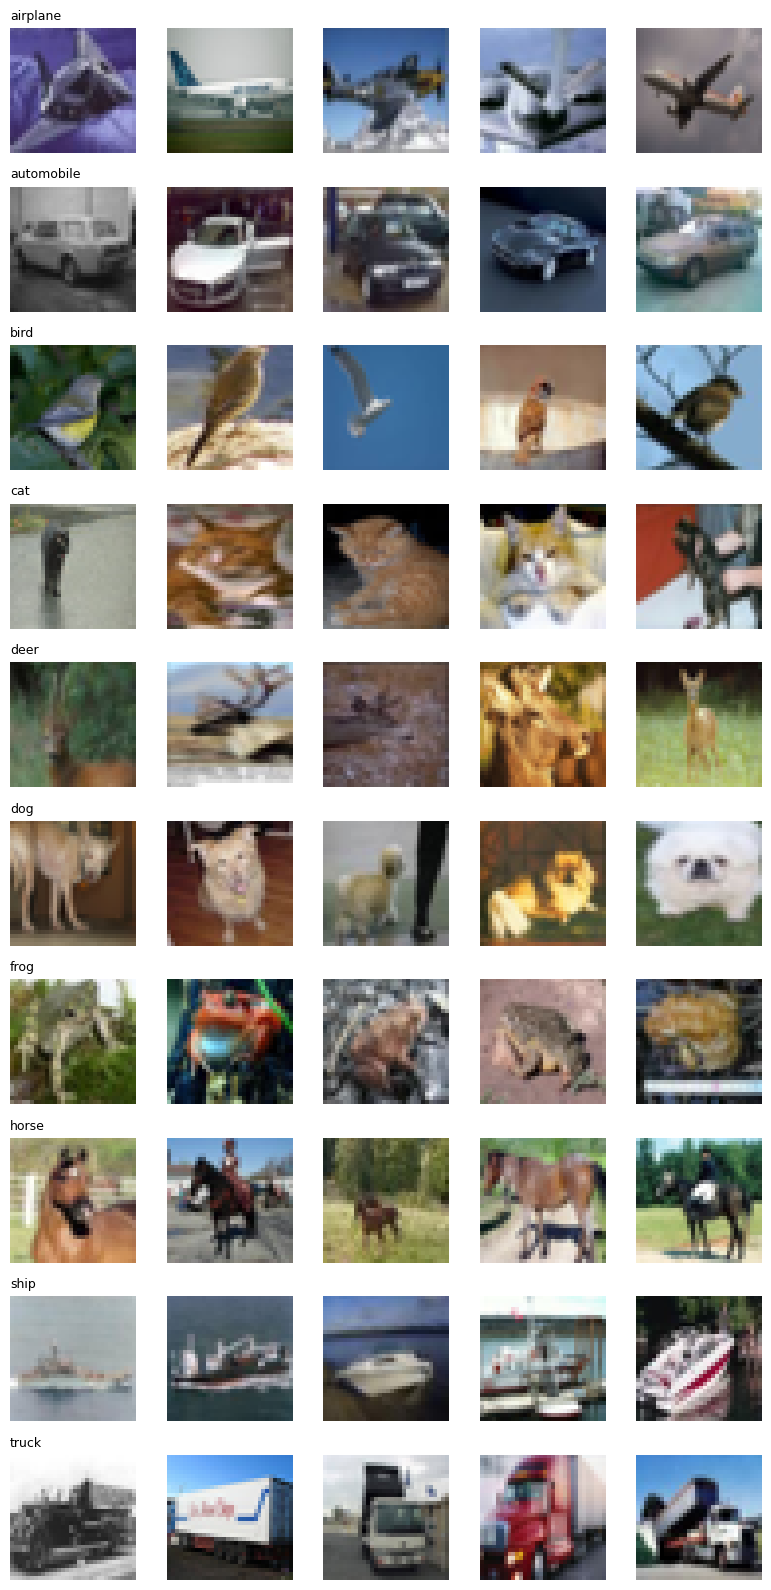

In [5]:
n_per_class = 5
fig, axes = plt.subplots(len(class_names), n_per_class, figsize=(n_per_class * 1.6, len(class_names) * 1.6))
rng = np.random.default_rng(SEED)
for c, name in enumerate(class_names):
    idxs = rng.choice(np.where(y_train_all == c)[0], n_per_class, replace=False)
    for j, i in enumerate(idxs):
        axes[c, j].imshow(X_train[i]); axes[c, j].axis("off")
    axes[c, 0].set_title(name, fontsize=9, loc="left")
plt.tight_layout(); plt.show()

**Pares de clases que esperamos más difíciles de distinguir:**
- **cat ↔ dog:** ambos son cuadrúpedos con pelaje, tamaños y poses similares; a 32×32 los rasgos finos (hocico, orejas) casi se pierden.
- **automobile ↔ truck:** formas rectangulares, ruedas y fondos de carretera parecidos; varían sobre todo en tamaño relativo.
- **deer ↔ horse:** siluetas y proporciones parecidas y fondos naturales (pasto, bosque).
- **airplane ↔ ship (y bird ↔ airplane):** fondos casi uniformes (cielo o mar azul) que hacen que el contexto sea engañoso.

Esto se verifica luego con las matrices de confusión.

### 2.4 Pipelines de preprocesamiento

In [6]:
# Augmentation (solo train) - opera sobre la imagen PIL de 32x32
augment = transforms.Compose([
    transforms.RandomCrop(32, padding=4),          # traslaciones pequeñas
    transforms.RandomHorizontalFlip(p=0.5),        # espejo horizontal
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
])

# --- CNN desde cero: resolución nativa 32x32, normalización con estadísticas de CIFAR-10
to_tensor_cnn = transforms.Compose([transforms.ToTensor(), transforms.Normalize(CIFAR_MEAN, CIFAR_STD)])
cnn_train_tf = transforms.Compose([augment, to_tensor_cnn])   # con augmentation
cnn_noaug_tf = to_tensor_cnn                                  # sin augmentation
cnn_eval_tf  = to_tensor_cnn                                  # val / test

# --- VGG-16: augmentation a 32x32, luego resize a VGG_RES + normalización ImageNet
VGG_RES = 128   # misma resolución para los dos modelos VGG-16 (ver justificación abajo)
to_tensor_vgg = transforms.Compose([
    transforms.Resize(VGG_RES), transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)])
vgg_train_tf = transforms.Compose([augment, to_tensor_vgg])
vgg_noaug_tf = to_tensor_vgg
vgg_eval_tf  = to_tensor_vgg

# Costo de pasar de 32x32 a resoluciones mayores
rows = []
for r in [32, 112, 128, 224]:
    rows.append({"resolución": f"{r}x{r}", "píxeles/imagen": r * r, "veces vs 32x32": (r * r) / (32 * 32)})
display(pd.DataFrame(rows))

,resolución,píxeles/imagen,veces vs 32x32
0,32x32,1024,1.00
1,112x112,12544,12.25
2,128x128,16384,16.00
3,224x224,50176,49.00


**Pasar de 32×32 a 224×224:** la imagen tiene 1,024 píxeles y pasa a 50,176, es decir **49 veces más píxeles**. Las activaciones intermedias y las operaciones de las capas convolucionales escalan de forma similar (los FLOPs por imagen y la memoria de activaciones crecen ~49×). Por eso la CNN pequeña entrena rápido en resolución nativa, mientras que VGG-16 a 224×224 es mucho más costoso. Usar 112 o 128 reduce el costo entre ~3× y ~4× frente a 224.

**Resolución elegida para VGG-16: 128×128.** Se usa la misma para el feature extractor y el fine-tuning. Frente a 224×224 reduce los píxeles, los FLOPs y la memoria de activaciones unas **3×** (16,384 vs 50,176 píxeles). Así las 7+ iteraciones de VGG-16 y el experimento con 10 % de datos caben en el tiempo de cómputo disponible (una GPU de laptop). Además, 128 = 32·4 es un múltiplo exacto de la imagen original y de la reducción total de VGG (÷32), por lo que el último mapa de features es de 4×4. Para usar la resolución original de ImageNet basta cambiar `VGG_RES = 224`. Como la resolución forma parte de la configuración guardada, los modelos VGG se reentrenarían solos.

### 2.5 Data augmentation

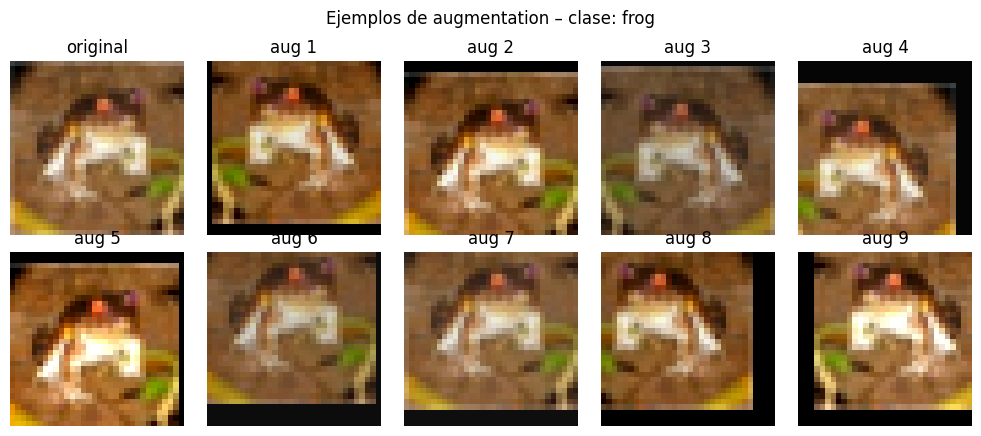

In [7]:
sample_img, sample_lbl = train_raw[0]
fig, axes = plt.subplots(2, 5, figsize=(10, 4.4))
axes[0, 0].imshow(sample_img); axes[0, 0].set_title("original"); axes[0, 0].axis("off")
for k in range(1, 10):
    ax = axes.flat[k]
    ax.imshow(augment(sample_img)); ax.set_title(f"aug {k}"); ax.axis("off")
plt.suptitle(f"Ejemplos de augmentation – clase: {class_names[sample_lbl]}")
plt.tight_layout(); plt.show()

**Técnicas usadas y por qué:**
- **RandomCrop con padding=4:** simula pequeñas traslaciones y hace al modelo robusto a la posición del objeto.
- **RandomHorizontalFlip:** un objeto espejado sigue siendo de la misma clase (no se usa flip vertical, porque un barco o un caballo al revés no es una imagen natural).
- **ColorJitter suave:** da robustez a cambios de iluminación y color sin destruir la información de clase.

**¿Por qué solo en entrenamiento?** La augmentation actúa como regularizador: aumenta la variedad de lo que ve el modelo al aprender. En validación y test se quiere medir el rendimiento sobre datos reales, sin modificar y de forma determinista y reproducible. Aumentar esos conjuntos alteraría la distribución de evaluación y haría las métricas ruidosas e incomparables entre modelos.

### 2.6 Split estratificado: train / validación / test

In [8]:
idx_all = np.arange(len(train_raw))
train_idx, val_idx = train_test_split(
    idx_all, test_size=5000, stratify=y_train_all, random_state=SEED)
print(f"Train: {len(train_idx):,} | Val: {len(val_idx):,} | Test (oficial): {len(test_raw):,}")
print("Por clase en train:", np.bincount(y_train_all[train_idx]))
print("Por clase en val:  ", np.bincount(y_train_all[val_idx]))

BATCH_SIZE = 128
NUM_WORKERS = 4      # procesos que cargan/aumentan el train en paralelo (poner 0 si hay problemas en Windows)
PIN = device.type == "cuda"

def make_loader(ds, indices=None, shuffle=False, batch_size=BATCH_SIZE, num_workers=0):
    d = Subset(ds, indices) if indices is not None else ds
    return DataLoader(d, batch_size=batch_size, shuffle=shuffle, num_workers=num_workers,
                      pin_memory=PIN, persistent_workers=num_workers > 0)

# Mismos datos base, distinta transformación según el modelo y el rol del subconjunto.
# val/test se cargan sin workers: son deterministas y pequeños, y así no quedan procesos extra en memoria.
DATA = {}
for fam, (tf_aug, tf_noaug, tf_eval) in {"cnn": (cnn_train_tf, cnn_noaug_tf, cnn_eval_tf),
                                         "vgg": (vgg_train_tf, vgg_noaug_tf, vgg_eval_tf)}.items():
    DATA[fam] = dict(
        train_aug   = datasets.CIFAR10("data", train=True,  transform=tf_aug,   download=False),
        train_noaug = datasets.CIFAR10("data", train=True,  transform=tf_noaug, download=False),
        val_loader  = make_loader(datasets.CIFAR10("data", train=True,  transform=tf_eval, download=False), val_idx),
        test_loader = make_loader(datasets.CIFAR10("data", train=False, transform=tf_eval, download=False)),
    )

for fam in DATA:
    x, _ = next(iter(DATA[fam]["val_loader"]))
    print(f"{fam}: batch de validación {tuple(x.shape)}")

Train: 45,000 | Val: 5,000 | Test (oficial): 10,000
Por clase en train: [4500 4500 4500 4500 4500 4500 4500 4500 4500 4500]
Por clase en val:   [500 500 500 500 500 500 500 500 500 500]
cnn: batch de validación (128, 3, 32, 32)
vgg: batch de validación (128, 3, 128, 128)


## 3. Utilidades de entrenamiento y evaluación
Estas funciones sirven para los tres modelos. Por iteración registran la configuración, las pérdidas y la accuracy de validación por epoch, las métricas de validación, el número de parámetros (totales y entrenables), el tiempo por epoch y el total, y la memoria pico de GPU.

- **Optimizador:** AdamW. Si la configuración trae `lr_backbone`, se crean dos **grupos de parámetros** (`param_groups`): las capas convolucionales descongeladas (`model.features`) usan `lr_backbone` y el clasificador usa `lr`.
- **Mejor epoch:** los pesos del epoch con menor pérdida de validación se guardan **solo en memoria** y se restauran al final del entrenamiento. No se escriben checkpoints a disco.
- **AMP (mixed precision):** se usa en GPU para acelerar el entrenamiento y la evaluación.

In [9]:
def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def autocast():
    return torch.autocast(device_type=device.type, enabled=device.type == "cuda")

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, n = 0.0, 0
    all_preds, all_labels = [], []
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        with autocast():
            out = model(x)
        total_loss += criterion(out.float(), y).item() * x.size(0)
        n += x.size(0)
        all_preds.append(out.argmax(1).cpu()); all_labels.append(y.cpu())
    return total_loss / n, torch.cat(all_preds).numpy(), torch.cat(all_labels).numpy()

def compute_metrics(y_true, y_pred):
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    return {"accuracy": accuracy_score(y_true, y_pred),
            "precision_macro": p, "recall_macro": r, "f1_macro": f1}

def trained_state(model):
    # Copia en CPU de lo que cambia al entrenar: parámetros entrenables + buffers (p. ej. BatchNorm).
    # Las capas congeladas no se copian: siempre son iguales a los pesos preentrenados de ImageNet.
    trainable = {n for n, p in model.named_parameters() if p.requires_grad}
    buffers = {n for n, _ in model.named_buffers()}
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()
            if k in trainable or k in buffers}

def make_optimizer(model, cfg):
    head, backbone = [], []
    for n, p in model.named_parameters():
        if not p.requires_grad:
            continue
        (backbone if cfg.get("lr_backbone") and n.startswith("features.") else head).append(p)
    groups = [{"params": head, "lr": cfg["lr"], "name": "clasificador"}]
    if backbone:
        groups.append({"params": backbone, "lr": cfg["lr_backbone"], "name": "backbone"})
    return torch.optim.AdamW(groups, weight_decay=cfg.get("weight_decay", 0.0))

def train_model(model, train_loader, val_loader, cfg, verbose=True):
    # Entrena con AdamW (+ coseno opcional, AMP en GPU y early stopping opcional).
    # Al terminar, el modelo queda con los pesos del epoch de menor pérdida de validación.
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = make_optimizer(model, cfg)
    scheduler = (torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg["epochs"])
                 if cfg.get("scheduler") == "cosine" else None)
    use_amp = cfg.get("amp", True) and device.type == "cuda"
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
    patience = cfg.get("patience", None)

    history = {"train_loss": [], "val_loss": [], "val_acc": [], "epoch_time": []}
    best_val, best_state, best_epoch, bad = float("inf"), None, 0, 0

    if device.type == "cuda":
        torch.cuda.synchronize(); torch.cuda.reset_peak_memory_stats()
    t_start = time.time()

    for epoch in range(1, cfg["epochs"] + 1):
        t0 = time.time()
        model.train()
        running, n = 0.0, 0
        for x, y in train_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type=device.type, enabled=use_amp):
                loss = criterion(model(x), y)
            scaler.scale(loss).backward()
            scaler.step(optimizer); scaler.update()
            running += loss.item() * x.size(0); n += x.size(0)
        if scheduler: scheduler.step()

        train_loss = running / n
        val_loss, y_pred, y_true = evaluate(model, val_loader, criterion)
        if device.type == "cuda": torch.cuda.synchronize()
        dt = time.time() - t0

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(accuracy_score(y_true, y_pred))
        history["epoch_time"].append(dt)

        if val_loss < best_val:
            best_val, best_epoch, bad = val_loss, epoch, 0
            best_state = trained_state(model)
        else:
            bad += 1

        if verbose:
            print(f"Epoch {epoch:03d}/{cfg['epochs']} | train {train_loss:.4f} | val {val_loss:.4f} "
                  f"| val acc {history['val_acc'][-1]:.4f} | {dt:.1f}s")
        if patience and bad >= patience:
            print(f"Early stopping en epoch {epoch} (mejor: {best_epoch})")
            break

    total_time = time.time() - t_start
    peak_mem = torch.cuda.max_memory_allocated() / 1024**2 if device.type == "cuda" else float("nan")
    model.load_state_dict(best_state, strict=False)
    return history, best_state, best_epoch, total_time, peak_mem

### 3.1 Persistencia: guardar / cargar modelos entrenados
Cada modelo se guarda **una sola vez, cuando termina de entrenar**, en `outputs/models/<nombre>.pt` (pesos finales + historial, métricas, tiempos y memoria). No hay checkpoints intermedios.

Antes de entrenar una iteración se busca ese archivo:
- **Existe y la configuración coincide:** se cargan los resultados y **no se reentrena**. Los pesos se leen del disco solo cuando se necesitan (evaluación en test, sección 7).
- **No existe, o cambió la configuración o el tamaño del train:** se entrena y se guarda al terminar.

Control manual:
- `FORCE_RETRAIN = True` reentrena todo.
- `RETRAIN_ONLY = {"cnn_wide_aug"}` reentrena solo esas iteraciones.
- También se puede borrar el `.pt` de una iteración para reentrenarla.

Para VGG-16 solo se guardan las capas entrenadas (clasificador y bloques descongelados). Las capas congeladas son exactamente los pesos de ImageNet y se reconstruyen al cargar. Los pesos se guardan en CPU, así que un modelo entrenado en GPU se puede cargar en una máquina sin GPU. Los tiempos y la memoria pico reportados son los de la corrida original.

In [10]:
MODELS_DIR = "outputs/models"         # un archivo .pt por modelo entrenado (versión final, sin checkpoints)
os.makedirs(MODELS_DIR, exist_ok=True)

FORCE_RETRAIN = False                 # True -> ignora los modelos guardados y reentrena todo
RETRAIN_ONLY = set()                  # p. ej. {"cnn_wide_aug"} -> reentrena solo esas iteraciones
RUN_FORMAT = 2                        # versión del formato del .pt; archivos de otra versión se reentrenan

runs = {}   # nombre -> dict con cfg, history, métricas, tiempos, etc. (los pesos quedan en disco)

def model_path(name):
    return os.path.join(MODELS_DIR, f"{name}.pt")

def save_run(name, state):
    # Escritura atómica: si se interrumpe, no queda un .pt corrupto
    path = model_path(name)
    tmp = path + ".tmp"
    torch.save({**runs[name], "best_state": state, "format": RUN_FORMAT}, tmp)
    os.replace(tmp, path)
    print(f"[guardado] {path} ({os.path.getsize(path)/1024**2:.1f} MB)")

def load_run(name, cfg, n_train):
    # Carga los resultados guardados en runs[name] si el .pt existe y es válido. Devuelve True si los cargó.
    path = model_path(name)
    if FORCE_RETRAIN or name in RETRAIN_ONLY:
        print(f"[reentrenar] '{name}' (forzado)")
        return False
    if not os.path.exists(path):
        print(f"[nuevo] no hay modelo guardado para '{name}' -> se entrena")
        return False
    # weights_only=False: el archivo contiene dicts/listas propios, no solo tensores (generados por este notebook)
    r = torch.load(path, map_location="cpu", weights_only=False)
    if r.get("format") != RUN_FORMAT or r.get("cfg") != cfg or r.get("n_train") != n_train:
        print(f"[obsoleto] el modelo guardado de '{name}' no coincide con la configuración/datos actuales -> se reentrena")
        return False
    r.pop("best_state"); r.pop("format")
    runs[name] = r
    return True

def build_model(cfg):
    if cfg["family"] == "cnn":
        return CNNScratch(**{k: cfg[k] for k in CNN_KEYS})
    if cfg["family"] == "vgg":
        return build_vgg(cfg)
    raise ValueError(cfg["family"])

def load_trained_model(name):
    # Reconstruye el modelo de una iteración y le carga desde disco sus pesos finales
    model = build_model(runs[name]["cfg"])
    state = torch.load(model_path(name), map_location="cpu", weights_only=False)["best_state"]
    missing, unexpected = model.load_state_dict(state, strict=False)
    params = dict(model.named_parameters())
    # lo único que puede faltar son capas congeladas (se quedan con los pesos de ImageNet)
    assert not unexpected and all(k in params and not params[k].requires_grad for k in missing)
    return model.to(device)

### 3.2 Ejecución de una iteración, tablas y gráficas
`run_experiment` es igual para los tres modelos: `cfg["family"]` decide la arquitectura (`"cnn"` o `"vgg"`) y el pipeline de datos.

In [11]:
def get_train_loader(cfg, indices):
    d = DATA[cfg["family"]]
    return make_loader(d["train_aug"] if cfg["augment"] else d["train_noaug"], indices,
                       shuffle=True, num_workers=NUM_WORKERS)

def run_experiment(name, cfg, train_indices=train_idx, verbose=True):
    # 1) si ya hay un modelo guardado válido, se carga y NO se entrena
    if load_run(name, cfg, len(train_indices)):
        r = runs[name]
        print(f"[cache] '{name}' cargado desde {model_path(name)} | "
              f"Val F1 macro: {r['metrics']['f1_macro']:.4f} | mejor epoch: {r['best_epoch']} | "
              f"tiempo original: {r['total_time']:.0f}s")
        return

    # 2) si no, se entrena y se guarda la versión final
    print(f"\n{'='*70}\n{name}\n{cfg}\n{'='*70}")
    set_seed()
    model = build_model(cfg)
    total_p, train_p = count_params(model)
    val_loader = DATA[cfg["family"]]["val_loader"]
    tr_loader = get_train_loader(cfg, train_indices)
    history, best_state, best_epoch, total_time, peak_mem = train_model(model, tr_loader, val_loader, cfg, verbose)
    del tr_loader   # libera los procesos de carga de datos

    val_loss, y_pred, y_true = evaluate(model, val_loader, nn.CrossEntropyLoss())
    metrics = {k: float(v) for k, v in compute_metrics(y_true, y_pred).items()}
    runs[name] = dict(cfg=cfg, n_train=len(train_indices), history=history,
                      best_epoch=best_epoch, epochs_run=len(history["train_loss"]),
                      metrics=metrics, val_loss=float(val_loss),
                      total_params=total_p, trainable_params=train_p,
                      mean_epoch_time=float(np.mean(history["epoch_time"])),
                      total_time=float(total_time), peak_mem_mb=float(peak_mem))
    save_run(name, best_state)
    print(f"-> Val: {metrics} | mejor epoch: {best_epoch} | tiempo total: {total_time:.0f}s")
    del model
    if device.type == "cuda": torch.cuda.empty_cache()

def frozen_desc(cfg):
    if cfg["family"] == "cnn":
        return "ninguna (todo entrenable)"
    k = cfg["unfrozen_blocks"]
    if k == 0:
        return "features completo (bloques 1-5)"
    return f"bloques 1-{5 - k}" if k < 5 else "ninguna"

FMT = {"acc": "{:.4f}", "precision": "{:.4f}", "recall": "{:.4f}", "F1 macro": "{:.4f}", "val loss": "{:.4f}",
       "s/epoch": "{:.1f}", "tiempo total (s)": "{:.0f}", "mem pico GPU (MB)": "{:.0f}",
       "params totales": "{:,}", "params entrenables": "{:,}"}

def summary_table(run_names):
    rows = []
    for n in run_names:
        r = runs[n]
        rows.append({
            "iteración": n, "capas congeladas": frozen_desc(r["cfg"]),
            "acc": r["metrics"]["accuracy"], "precision": r["metrics"]["precision_macro"],
            "recall": r["metrics"]["recall_macro"], "F1 macro": r["metrics"]["f1_macro"],
            "val loss": r["val_loss"], "mejor epoch": r["best_epoch"], "epochs corridos": r["epochs_run"],
            "params totales": r["total_params"], "params entrenables": r["trainable_params"],
            "s/epoch": r["mean_epoch_time"], "tiempo total (s)": r["total_time"],
            "mem pico GPU (MB)": r["peak_mem_mb"],
        })
    return pd.DataFrame(rows).set_index("iteración")

def show_iterations(run_names):
    df = summary_table(run_names)
    display(df.style.format(FMT))
    display(pd.DataFrame({n: runs[n]["cfg"] for n in run_names}).T)   # hiperparámetros por iteración
    return df

def plot_curves(run_names):
    fig, axes = plt.subplots(1, len(run_names), figsize=(5 * len(run_names), 3.8), squeeze=False)
    for ax, n in zip(axes[0], run_names):
        h = runs[n]["history"]
        ep = range(1, len(h["train_loss"]) + 1)
        ax.plot(ep, h["train_loss"], label="train")
        ax.plot(ep, h["val_loss"], label="val")
        ax.axvline(runs[n]["best_epoch"], ls="--", c="gray", lw=0.8, label="mejor epoch")
        ax.set_title(n); ax.set_xlabel("epoch"); ax.set_ylabel("loss"); ax.legend(); ax.grid(alpha=.3)
    plt.tight_layout(); plt.show()

def plot_confusion(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(10)); ax.set_yticks(range(10))
    ax.set_xticklabels(class_names, rotation=45, ha="right"); ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicho"); ax.set_ylabel("Real"); ax.set_title(title, fontsize=10)
    for i in range(10):
        for j in range(10):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=7)
    return cm

## 4. Modelo 1: CNN desde cero
Arquitectura con **bloques convolucionales** `[Conv → BN → ReLU] × 2 → MaxPool → Dropout`, seguidos de un clasificador totalmente conectado con dropout. Los canales, el dropout y la cantidad de bloques son configurables para iterar.

In [12]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, convs=2, p_drop=0.0):
        super().__init__()
        layers = []
        for i in range(convs):
            layers += [nn.Conv2d(in_ch if i == 0 else out_ch, out_ch, 3, padding=1, bias=False),
                       nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)]
        layers += [nn.MaxPool2d(2), nn.Dropout2d(p_drop) if p_drop > 0 else nn.Identity()]
        self.block = nn.Sequential(*layers)
    def forward(self, x): return self.block(x)

class CNNScratch(nn.Module):
    def __init__(self, channels=(32, 64, 128), convs_per_block=2, dropout_conv=0.1,
                 dropout_fc=0.5, fc_units=256, num_classes=10, in_ch=3, img_size=32):
        super().__init__()
        blocks, c_in = [], in_ch
        for c in channels:
            blocks.append(ConvBlock(c_in, c, convs_per_block, dropout_conv)); c_in = c
        self.features = nn.Sequential(*blocks)
        spatial = img_size // (2 ** len(channels))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(c_in * spatial * spatial, fc_units), nn.BatchNorm1d(fc_units), nn.ReLU(inplace=True),
            nn.Dropout(dropout_fc),
            nn.Linear(fc_units, num_classes))
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x): return self.classifier(self.features(x))

CNN_KEYS = ["channels", "convs_per_block", "dropout_conv", "dropout_fc", "fc_units"]

# Chequeo rápido de dimensiones
m = CNNScratch()
print(m(torch.randn(2, 3, 32, 32)).shape, "| params (total, entrenables):", count_params(m))

torch.Size([2, 10]) | params (total, entrenables): (815082, 815082)


### 4.1 Iteraciones de hiperparámetros
Se prueban 4 configuraciones para identificar overfitting y underfitting:

| Iteración | Idea |
|---|---|
| `cnn_base_noaug` | Baseline sin augmentation ni regularización conv (esperamos overfitting) |
| `cnn_base_aug` | Mismo modelo con augmentation + dropout conv |
| `cnn_wide_aug` | Más canales, weight decay y scheduler coseno |
| `cnn_wide_reg` | Más regularización (dropout conv/wd) y más epochs |

In [13]:
cnn_experiments = {
    "cnn_base_noaug": dict(family="cnn", channels=(32, 64, 128), convs_per_block=2, dropout_conv=0.0, dropout_fc=0.5,
                           fc_units=256, lr=1e-3, weight_decay=0.0, scheduler=None,
                           epochs=20, augment=False),
    "cnn_base_aug":   dict(family="cnn", channels=(32, 64, 128), convs_per_block=2, dropout_conv=0.1, dropout_fc=0.5,
                           fc_units=256, lr=1e-3, weight_decay=5e-4, scheduler=None,
                           epochs=30, augment=True),
    "cnn_wide_aug":   dict(family="cnn", channels=(64, 128, 256), convs_per_block=2, dropout_conv=0.2, dropout_fc=0.5,
                           fc_units=512, lr=2e-3, weight_decay=5e-4, scheduler="cosine",
                           epochs=40, augment=True),
    "cnn_wide_reg":   dict(family="cnn", channels=(64, 128, 256), convs_per_block=2, dropout_conv=0.3, dropout_fc=0.5,
                           fc_units=512, lr=2e-3, weight_decay=1e-3, scheduler="cosine",
                           epochs=50, augment=True),
}

for name, cfg in cnn_experiments.items():
    run_experiment(name, cfg)

[nuevo] no hay modelo guardado para 'cnn_base_noaug' -> se entrena

cnn_base_noaug
{'family': 'cnn', 'channels': (32, 64, 128), 'convs_per_block': 2, 'dropout_conv': 0.0, 'dropout_fc': 0.5, 'fc_units': 256, 'lr': 0.001, 'weight_decay': 0.0, 'scheduler': None, 'epochs': 20, 'augment': False}
Epoch 001/20 | train 1.3453 | val 0.9809 | val acc 0.6542 | 41.4s
Epoch 002/20 | train 0.8740 | val 0.7735 | val acc 0.7264 | 4.3s
Epoch 003/20 | train 0.6946 | val 0.7395 | val acc 0.7430 | 3.9s
Epoch 004/20 | train 0.5876 | val 0.7003 | val acc 0.7582 | 3.9s
Epoch 005/20 | train 0.4948 | val 0.6312 | val acc 0.7846 | 4.1s
Epoch 006/20 | train 0.4110 | val 0.6064 | val acc 0.7894 | 4.1s
Epoch 007/20 | train 0.3442 | val 0.6772 | val acc 0.7802 | 4.2s
Epoch 008/20 | train 0.2816 | val 0.7675 | val acc 0.7676 | 4.1s
Epoch 009/20 | train 0.2413 | val 0.7600 | val acc 0.7802 | 4.0s
Epoch 010/20 | train 0.2042 | val 0.7415 | val acc 0.7860 | 3.9s
Epoch 011/20 | train 0.1657 | val 0.7785 | val acc 0.7892

### 4.2 Resumen de iteraciones (validación)

In [14]:
results_cnn = show_iterations(list(cnn_experiments))

,capas congeladas,acc,precision,recall,F1 macro,val loss,mejor epoch,epochs corridos,params totales,params entrenables,s/epoch,tiempo total (s),mem pico GPU (MB)
iteración,,,,,,,,,,,,,
cnn_base_noaug,ninguna (todo entrenable),0.7894,0.7938,0.7894,0.7903,0.6064,6,20,"815,082","815,082",6.2,124,196
cnn_base_aug,ninguna (todo entrenable),0.8660,0.8691,0.8660,0.8646,0.3842,30,30,"815,082","815,082",8.1,243,106
cnn_wide_aug,ninguna (todo entrenable),0.9148,0.9150,0.9148,0.9145,0.2715,37,40,"3,250,122","3,250,122",8.1,324,412
cnn_wide_reg,ninguna (todo entrenable),0.9076,0.9075,0.9076,0.9070,0.2714,50,50,"3,250,122","3,250,122",7.6,381,220


,family,channels,convs_per_block,dropout_conv,dropout_fc,fc_units,lr,weight_decay,scheduler,epochs,augment
cnn_base_noaug,cnn,"(32, 64, 128)",2,0.0,0.5,256,0.001,0.0,None,20,False
cnn_base_aug,cnn,"(32, 64, 128)",2,0.1,0.5,256,0.001,0.0005,None,30,True
cnn_wide_aug,cnn,"(64, 128, 256)",2,0.2,0.5,512,0.002,0.0005,cosine,40,True
cnn_wide_reg,cnn,"(64, 128, 256)",2,0.3,0.5,512,0.002,0.001,cosine,50,True


### 4.3 Curvas de pérdida (train vs validación)

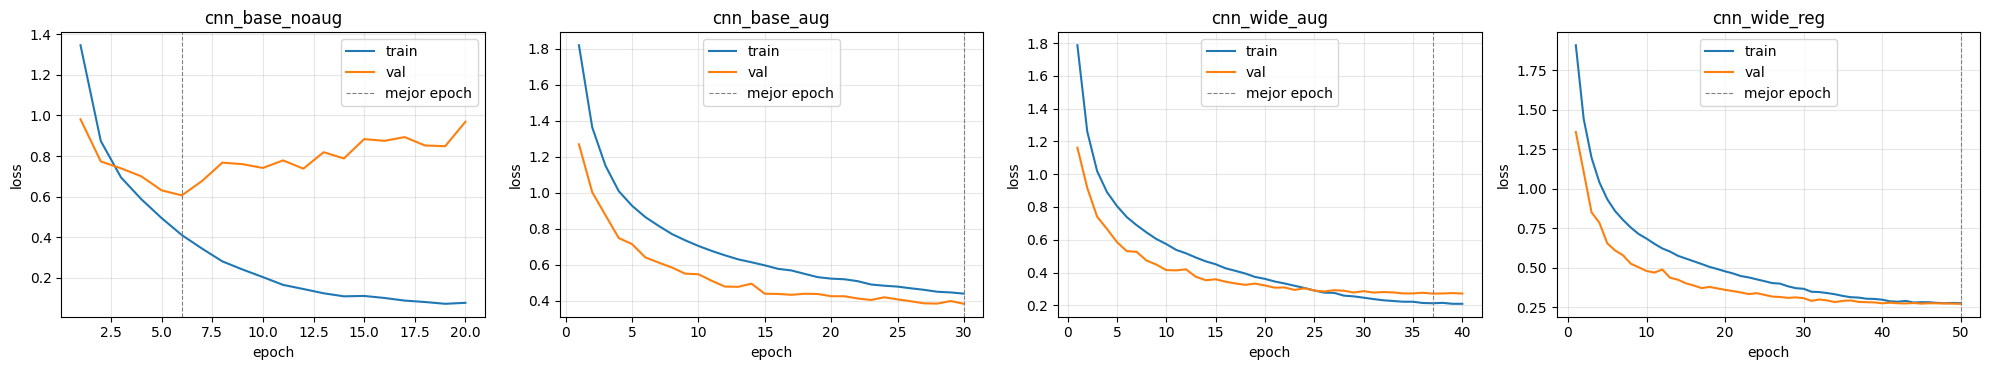

In [15]:
plot_curves(list(cnn_experiments))

**Interpretación** *(completar con los resultados obtenidos)*:
- `cnn_base_noaug`: si la pérdida de train sigue bajando mientras la de validación sube, hay **overfitting**.
- `cnn_base_aug`: la augmentation debería cerrar la brecha train-val.
- `cnn_wide_*`: un modelo más grande con más regularización debería bajar la pérdida de validación. Si ambas curvas se mantienen altas y juntas, sería **underfitting**.

### 4.4 Mejor configuración (según F1 macro en validación)

In [16]:
best_cnn = results_cnn["F1 macro"].idxmax()
print("Mejor iteración CNN:", best_cnn)
print(runs[best_cnn]["cfg"])

Mejor iteración CNN: cnn_wide_aug
{'family': 'cnn', 'channels': (64, 128, 256), 'convs_per_block': 2, 'dropout_conv': 0.2, 'dropout_fc': 0.5, 'fc_units': 512, 'lr': 0.002, 'weight_decay': 0.0005, 'scheduler': 'cosine', 'epochs': 40, 'augment': True}


## 5. Modelo 2: VGG-16 como feature extractor
Se carga VGG-16 con pesos de ImageNet (`VGG16_Weights.IMAGENET1K_V1`). La red tiene tres partes:
- `model.features`: 13 convoluciones en **5 bloques**, cada uno terminado en `MaxPool2d`.
- `model.avgpool`: `AdaptiveAvgPool2d((7, 7))`. Deja la salida en 512×7×7 sin importar la resolución de entrada (con 128×128 el mapa de 4×4 se lleva a 7×7).
- `model.classifier`: `Linear(25088, 4096) → ReLU → Dropout → Linear(4096, 4096) → ReLU → Dropout → Linear(4096, 1000)`.

`build_vgg` congela todo `model.features` (`requires_grad = False`) y reemplaza la última capa por `Linear(4096, 10)`. Con `unfrozen_blocks = k` se descongelan los `k` bloques superiores, y esa misma función sirve para el fine-tuning (sección 6). VGG-16 no tiene BatchNorm, así que `model.train()` solo activa el dropout del clasificador y no altera las capas congeladas.

In [17]:
# Índices de cada bloque convolucional dentro de model.features (cada bloque termina en un MaxPool2d)
VGG_BLOCKS = {1: range(0, 5), 2: range(5, 10), 3: range(10, 17), 4: range(17, 24), 5: range(24, 31)}

def build_vgg(cfg):
    model = vgg16(weights=VGG16_Weights.IMAGENET1K_V1)
    for p in model.features.parameters():                  # congela todo el backbone
        p.requires_grad = False
    for b in range(6 - cfg["unfrozen_blocks"], 6):          # descongela los bloques superiores
        for i in VGG_BLOCKS[b]:
            for p in model.features[i].parameters():
                p.requires_grad = True
    model.classifier[2].p = model.classifier[5].p = cfg["dropout"]
    model.classifier[6] = nn.Linear(4096, 10)               # nueva capa de salida (10 clases)
    return model

m = build_vgg(dict(unfrozen_blocks=0, dropout=0.5))
print(m)
for k in range(4):
    print(f"bloques descongelados = {k}: params (total, entrenables) =",
          count_params(build_vgg(dict(unfrozen_blocks=k, dropout=0.5))))
del m

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

### 5.1 Iteraciones de hiperparámetros
En todas las iteraciones el backbone está completamente congelado y solo se entrena el clasificador (≈119.6 M parámetros).

| Iteración | Idea |
|---|---|
| `vgg_fe_noaug` | lr 1e-4 sin augmentation. El clasificador es muy grande y se espera overfitting rápido |
| `vgg_fe_aug` | Mismo lr con augmentation y weight decay |
| `vgg_fe_aug_lr1e-3` | lr 10× mayor, para ver la sensibilidad al learning rate |

In [18]:
vgg_base = dict(family="vgg", res=VGG_RES, unfrozen_blocks=0, dropout=0.5, lr=1e-4, weight_decay=5e-4,
                scheduler="cosine", epochs=10, patience=3, augment=True)

fe_experiments = {
    "vgg_fe_noaug":      {**vgg_base, "augment": False, "weight_decay": 0.0},
    "vgg_fe_aug":        {**vgg_base},
    "vgg_fe_aug_lr1e-3": {**vgg_base, "lr": 1e-3},
}

for name, cfg in fe_experiments.items():
    run_experiment(name, cfg)

[nuevo] no hay modelo guardado para 'vgg_fe_noaug' -> se entrena

vgg_fe_noaug
{'family': 'vgg', 'res': 128, 'unfrozen_blocks': 0, 'dropout': 0.5, 'lr': 0.0001, 'weight_decay': 0.0, 'scheduler': 'cosine', 'epochs': 10, 'patience': 3, 'augment': False}
Epoch 001/10 | train 0.5206 | val 0.3671 | val acc 0.8722 | 75.1s
Epoch 002/10 | train 0.3008 | val 0.3207 | val acc 0.8858 | 59.6s
Epoch 003/10 | train 0.1907 | val 0.3213 | val acc 0.8946 | 60.9s
Epoch 004/10 | train 0.1146 | val 0.3264 | val acc 0.8952 | 64.8s
Epoch 005/10 | train 0.0602 | val 0.3482 | val acc 0.8974 | 60.6s
Early stopping en epoch 5 (mejor: 2)
[guardado] outputs/models\vgg_fe_noaug.pt (456.2 MB)
-> Val: {'accuracy': 0.8858, 'precision_macro': 0.8871211219403186, 'recall_macro': 0.8858, 'f1_macro': 0.8856951970183766} | mejor epoch: 2 | tiempo total: 322s
[nuevo] no hay modelo guardado para 'vgg_fe_aug' -> se entrena

vgg_fe_aug
{'family': 'vgg', 'res': 128, 'unfrozen_blocks': 0, 'dropout': 0.5, 'lr': 0.0001, 'weight_d

### 5.2 Resumen de iteraciones (validación)

In [19]:
results_fe = show_iterations(list(fe_experiments))

,capas congeladas,acc,precision,recall,F1 macro,val loss,mejor epoch,epochs corridos,params totales,params entrenables,s/epoch,tiempo total (s),mem pico GPU (MB)
iteración,,,,,,,,,,,,,
vgg_fe_noaug,features completo (bloques 1-5),0.8858,0.8871,0.8858,0.8857,0.3207,2,5,"134,301,514","119,586,826",64.2,322,4970
vgg_fe_aug,features completo (bloques 1-5),0.8968,0.8967,0.8968,0.8967,0.2835,10,10,"134,301,514","119,586,826",63.3,635,2959
vgg_fe_aug_lr1e-3,features completo (bloques 1-5),0.8950,0.8950,0.8950,0.8949,0.3219,10,10,"134,301,514","119,586,826",66.0,662,2959


,family,res,unfrozen_blocks,dropout,lr,weight_decay,scheduler,epochs,patience,augment
vgg_fe_noaug,vgg,128,0,0.5,0.0001,0.0,cosine,10,3,False
vgg_fe_aug,vgg,128,0,0.5,0.0001,0.0005,cosine,10,3,True
vgg_fe_aug_lr1e-3,vgg,128,0,0.5,0.001,0.0005,cosine,10,3,True


### 5.3 Curvas de pérdida (train vs validación)

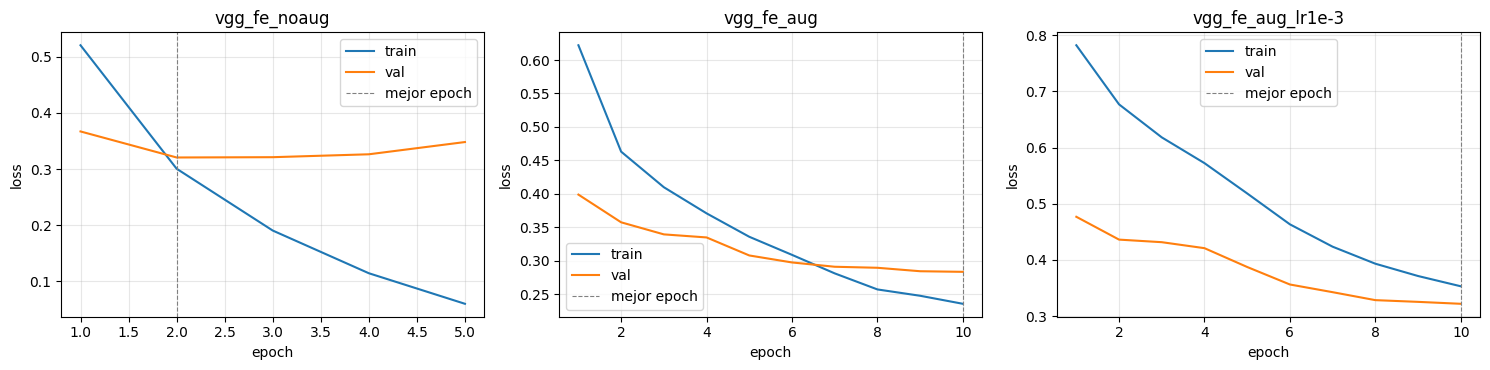

In [20]:
plot_curves(list(fe_experiments))

**Interpretación** *(completar con los resultados obtenidos)*: comparar la brecha train-val con y sin augmentation, y el efecto del learning rate.

### 5.4 Mejor configuración (según F1 macro en validación)

In [21]:
best_fe = results_fe["F1 macro"].idxmax()
print("Mejor iteración VGG-16 feature extractor:", best_fe)
print(runs[best_fe]["cfg"])

Mejor iteración VGG-16 feature extractor: vgg_fe_aug
{'family': 'vgg', 'res': 128, 'unfrozen_blocks': 0, 'dropout': 0.5, 'lr': 0.0001, 'weight_decay': 0.0005, 'scheduler': 'cosine', 'epochs': 10, 'patience': 3, 'augment': True}


## 6. Modelo 3: VGG-16 con fine-tuning
Se parte del mismo modelo preentrenado y se descongelan los bloques convolucionales superiores. Se entrenan junto con el clasificador usando **dos grupos de parámetros** en el optimizador: el backbone con `lr_backbone` (menor) y el clasificador con `lr`.

| Iteración | Bloques descongelados | lr clasificador | lr backbone |
|---|---|---|---|
| `vgg_ft_b5` | 5 | 1e-4 | 1e-5 |
| `vgg_ft_b45` | 4 y 5 | 1e-4 | 1e-5 |
| `vgg_ft_b345` | 3, 4 y 5 | 1e-4 | 1e-5 |
| `vgg_ft_b45_lrbb5e-5` | 4 y 5 | 1e-4 | 5e-5 |

Las tres primeras varían el número de bloques descongelados. La última varía el learning rate del backbone.

In [22]:
ft_base = {**vgg_base, "lr": 1e-4, "lr_backbone": 1e-5}

ft_experiments = {
    "vgg_ft_b5":           {**ft_base, "unfrozen_blocks": 1},
    "vgg_ft_b45":          {**ft_base, "unfrozen_blocks": 2},
    "vgg_ft_b345":         {**ft_base, "unfrozen_blocks": 3},
    "vgg_ft_b45_lrbb5e-5": {**ft_base, "unfrozen_blocks": 2, "lr_backbone": 5e-5},
}

for name, cfg in ft_experiments.items():
    run_experiment(name, cfg)

[nuevo] no hay modelo guardado para 'vgg_ft_b5' -> se entrena

vgg_ft_b5
{'family': 'vgg', 'res': 128, 'unfrozen_blocks': 1, 'dropout': 0.5, 'lr': 0.0001, 'weight_decay': 0.0005, 'scheduler': 'cosine', 'epochs': 10, 'patience': 3, 'augment': True, 'lr_backbone': 1e-05}
Epoch 001/10 | train 0.5667 | val 0.3472 | val acc 0.8810 | 83.6s
Epoch 002/10 | train 0.3806 | val 0.3035 | val acc 0.8956 | 66.6s
Epoch 003/10 | train 0.3135 | val 0.2847 | val acc 0.9006 | 67.1s
Epoch 004/10 | train 0.2707 | val 0.2735 | val acc 0.9086 | 67.0s
Epoch 005/10 | train 0.2331 | val 0.2576 | val acc 0.9138 | 67.9s
Epoch 006/10 | train 0.2031 | val 0.2496 | val acc 0.9190 | 67.2s
Epoch 007/10 | train 0.1771 | val 0.2426 | val acc 0.9196 | 68.7s
Epoch 008/10 | train 0.1541 | val 0.2478 | val acc 0.9194 | 68.6s
Epoch 009/10 | train 0.1460 | val 0.2392 | val acc 0.9248 | 67.0s
Epoch 010/10 | train 0.1350 | val 0.2396 | val acc 0.9254 | 67.0s
[guardado] outputs/models\vgg_ft_b5.pt (483.2 MB)
-> Val: {'accuracy':

### 6.1 Resumen de iteraciones (validación)

In [23]:
results_ft = show_iterations(list(ft_experiments))

,capas congeladas,acc,precision,recall,F1 macro,val loss,mejor epoch,epochs corridos,params totales,params entrenables,s/epoch,tiempo total (s),mem pico GPU (MB)
iteración,,,,,,,,,,,,,
vgg_ft_b5,bloques 1-4,0.9248,0.9248,0.9248,0.9247,0.2392,9,10,"134,301,514","126,666,250",69.1,693,3040
vgg_ft_b45,bloques 1-3,0.9352,0.9350,0.9352,0.9351,0.2062,7,10,"134,301,514","132,566,026",82.7,828,3109
vgg_ft_b345,bloques 1-2,0.9450,0.9449,0.9450,0.9449,0.1890,9,10,"134,301,514","134,041,354",98.7,988,3128
vgg_ft_b45_lrbb5e-5,bloques 1-3,0.9380,0.9381,0.9380,0.9379,0.1859,3,6,"134,301,514","132,566,026",82.2,494,3108


,family,res,unfrozen_blocks,dropout,lr,weight_decay,scheduler,epochs,patience,augment,lr_backbone
vgg_ft_b5,vgg,128,1,0.5,0.0001,0.0005,cosine,10,3,True,0.00001
vgg_ft_b45,vgg,128,2,0.5,0.0001,0.0005,cosine,10,3,True,0.00001
vgg_ft_b345,vgg,128,3,0.5,0.0001,0.0005,cosine,10,3,True,0.00001
vgg_ft_b45_lrbb5e-5,vgg,128,2,0.5,0.0001,0.0005,cosine,10,3,True,0.00005


### 6.2 Curvas de pérdida (train vs validación)

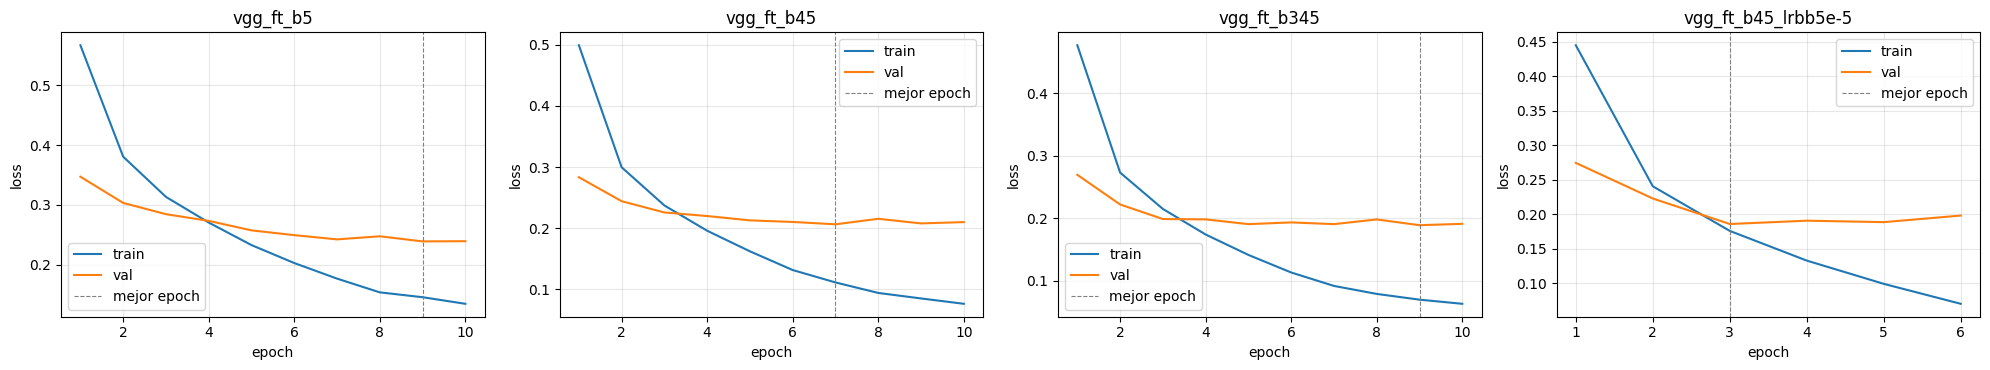

In [24]:
plot_curves(list(ft_experiments))

**Interpretación** *(completar con los resultados obtenidos)*: efecto del número de bloques descongelados y del lr del backbone; revisar si hay señales de overfitting (val loss sube mientras train baja) o de catastrophic forgetting (el desempeño cae por debajo del feature extractor).

### 6.3 Mejor configuración (según F1 macro en validación)

In [25]:
best_ft = results_ft["F1 macro"].idxmax()
print("Mejor iteración VGG-16 fine-tuning:", best_ft)
print(runs[best_ft]["cfg"])

BEST = {"CNN desde cero": best_cnn, "VGG-16 feature extractor": best_fe, "VGG-16 fine-tuning": best_ft}
display(summary_table(list(BEST.values())).style.format(FMT))

Mejor iteración VGG-16 fine-tuning: vgg_ft_b345
{'family': 'vgg', 'res': 128, 'unfrozen_blocks': 3, 'dropout': 0.5, 'lr': 0.0001, 'weight_decay': 0.0005, 'scheduler': 'cosine', 'epochs': 10, 'patience': 3, 'augment': True, 'lr_backbone': 1e-05}


,capas congeladas,acc,precision,recall,F1 macro,val loss,mejor epoch,epochs corridos,params totales,params entrenables,s/epoch,tiempo total (s),mem pico GPU (MB)
iteración,,,,,,,,,,,,,
cnn_wide_aug,ninguna (todo entrenable),0.9148,0.9150,0.9148,0.9145,0.2715,37,40,"3,250,122","3,250,122",8.1,324,412
vgg_fe_aug,features completo (bloques 1-5),0.8968,0.8967,0.8968,0.8967,0.2835,10,10,"134,301,514","119,586,826",63.3,635,2959
vgg_ft_b345,bloques 1-2,0.9450,0.9449,0.9450,0.9449,0.1890,9,10,"134,301,514","134,041,354",98.7,988,3128


## 7. Evaluación final en test (una única vez)
Los pesos finales de la mejor iteración de cada modelo se cargan desde disco y se evalúan **una sola vez** sobre el test oficial.

In [26]:
test_results, test_preds = {}, {}
for label, name in BEST.items():
    model = load_trained_model(name)
    test_loss, y_pred, y_true = evaluate(model, DATA[runs[name]["cfg"]["family"]]["test_loader"], nn.CrossEntropyLoss())
    test_results[label] = {**compute_metrics(y_true, y_pred), "test loss": test_loss}
    test_preds[label] = (y_true, y_pred)
    print(f"\n{'='*70}\n{label} ({name})\n{'='*70}")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
    del model

test_df = pd.DataFrame(test_results).T
display(test_df.round(4))


CNN desde cero (cnn_wide_aug)
              precision    recall  f1-score   support

    airplane     0.9173    0.9100    0.9137      1000
  automobile     0.9572    0.9620    0.9596      1000
        bird     0.8864    0.8660    0.8761      1000
         cat     0.8550    0.7490    0.7985      1000
        deer     0.8971    0.9240    0.9103      1000
         dog     0.8197    0.8730    0.8455      1000
        frog     0.9287    0.9380    0.9333      1000
       horse     0.9313    0.9490    0.9401      1000
        ship     0.9489    0.9470    0.9479      1000
       truck     0.9270    0.9530    0.9398      1000

    accuracy                         0.9071     10000
   macro avg     0.9069    0.9071    0.9065     10000
weighted avg     0.9069    0.9071    0.9065     10000


VGG-16 feature extractor (vgg_fe_aug)
              precision    recall  f1-score   support

    airplane     0.9149    0.9140    0.9145      1000
  automobile     0.9337    0.9430    0.9383      1000
        

,accuracy,precision_macro,recall_macro,f1_macro,test loss
CNN desde cero,0.9071,0.9069,0.9071,0.9065,0.2860
VGG-16 feature extractor,0.8977,0.8973,0.8977,0.8974,0.3034
VGG-16 fine-tuning,0.9401,0.9400,0.9401,0.9400,0.2125


CNN desde cero – pares más confundidos (real -> predicho): cat->dog (132), dog->cat (54), automobile->truck (30), cat->deer (28), airplane->ship (27)
VGG-16 feature extractor – pares más confundidos (real -> predicho): cat->dog (100), dog->cat (100), bird->deer (47), truck->automobile (46), automobile->truck (41)
VGG-16 fine-tuning – pares más confundidos (real -> predicho): cat->dog (72), dog->cat (55), truck->automobile (33), automobile->truck (31), ship->airplane (23)


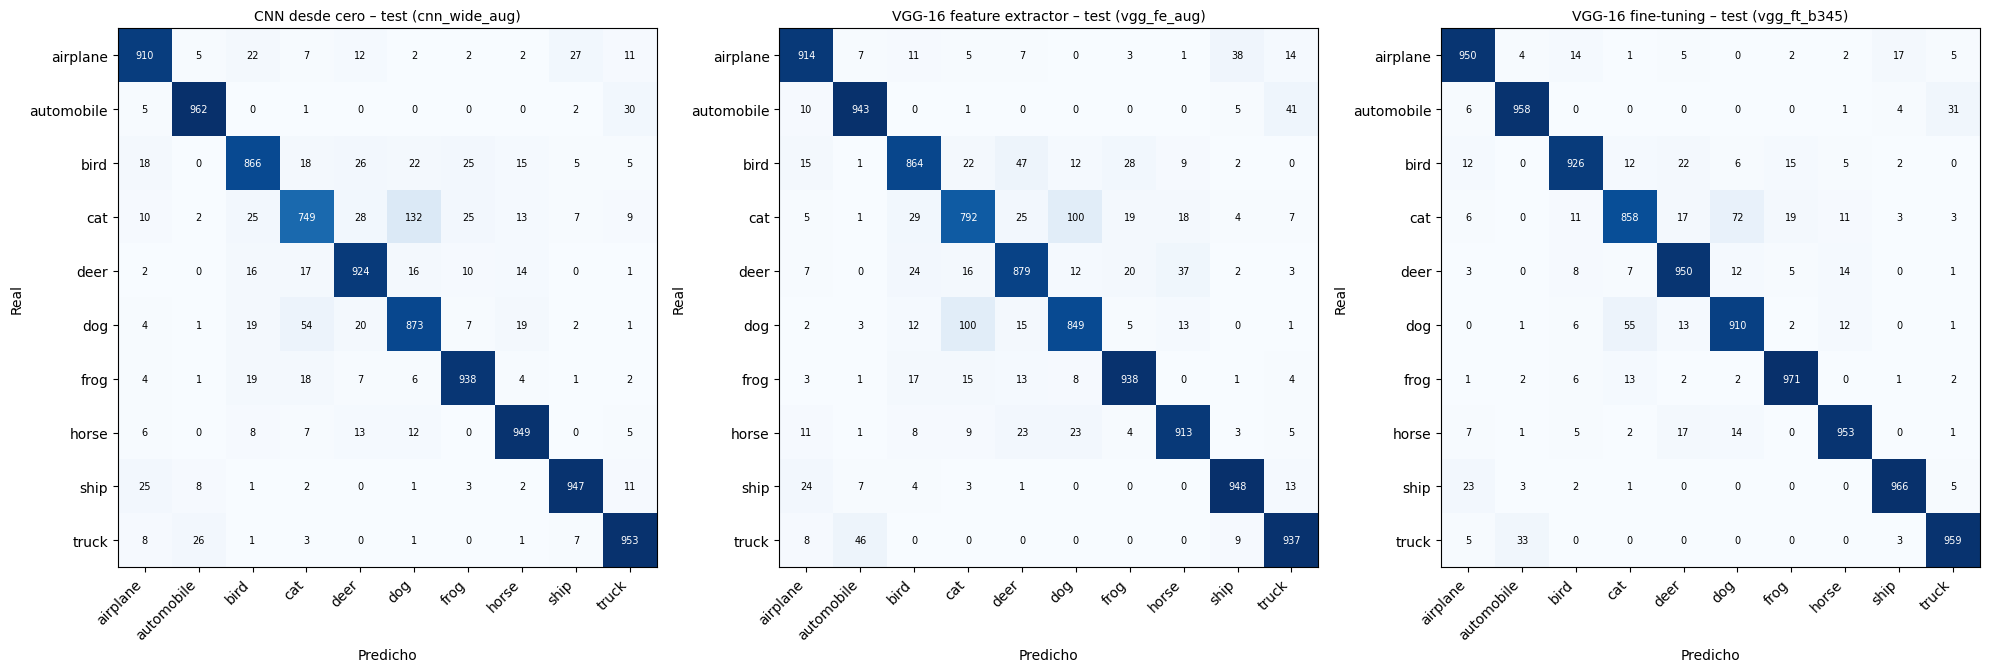

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6.5))
for ax, (label, (y_true, y_pred)) in zip(axes, test_preds.items()):
    cm = plot_confusion(y_true, y_pred, f"{label} – test ({BEST[label]})", ax)
    # Pares más confundidos
    cm_off = cm.copy(); np.fill_diagonal(cm_off, 0)
    top = np.dstack(np.unravel_index(np.argsort(-cm_off.ravel())[:5], cm.shape))[0]
    print(f"{label} – pares más confundidos (real -> predicho): " +
          ", ".join(f"{class_names[i]}->{class_names[j]} ({cm[i, j]})" for i, j in top))
plt.tight_layout(); plt.show()

## 8. Experimento adicional 4.1: efecto de la cantidad de datos
La mejor configuración de cada modelo se vuelve a entrenar con solo el **10 % del conjunto de entrenamiento**, estratificado por clase (450 imágenes por clase). Se evalúa sobre el mismo test, con la misma validación. Estos modelos también se guardan, así que no se reentrenan al volver a ejecutar.

In [28]:
FRACTION = 0.10
small_idx, _ = train_test_split(train_idx, train_size=FRACTION, stratify=y_train_all[train_idx], random_state=SEED)
print(f"Subconjunto: {len(small_idx):,} imágenes | por clase: {np.bincount(y_train_all[small_idx])}")

BEST_SMALL = {label: f"{name}_{int(FRACTION * 100)}pct" for label, name in BEST.items()}
for label, name in BEST.items():
    run_experiment(BEST_SMALL[label], runs[name]["cfg"], train_indices=small_idx)

Subconjunto: 4,500 imágenes | por clase: [450 450 450 450 450 450 450 450 450 450]
[nuevo] no hay modelo guardado para 'cnn_wide_aug_10pct' -> se entrena

cnn_wide_aug_10pct
{'family': 'cnn', 'channels': (64, 128, 256), 'convs_per_block': 2, 'dropout_conv': 0.2, 'dropout_fc': 0.5, 'fc_units': 512, 'lr': 0.002, 'weight_decay': 0.0005, 'scheduler': 'cosine', 'epochs': 40, 'augment': True}
Epoch 001/40 | train 2.4256 | val 1.8541 | val acc 0.3456 | 25.4s
Epoch 002/40 | train 2.0026 | val 1.6418 | val acc 0.3928 | 1.8s
Epoch 003/40 | train 1.8698 | val 1.5556 | val acc 0.4276 | 2.1s
Epoch 004/40 | train 1.7983 | val 1.5582 | val acc 0.4404 | 2.0s
Epoch 005/40 | train 1.7091 | val 1.4046 | val acc 0.4806 | 2.0s
Epoch 006/40 | train 1.6124 | val 1.3591 | val acc 0.5112 | 2.0s
Epoch 007/40 | train 1.5652 | val 1.3013 | val acc 0.5170 | 1.9s
Epoch 008/40 | train 1.5139 | val 1.3008 | val acc 0.5262 | 2.0s
Epoch 009/40 | train 1.4657 | val 1.2497 | val acc 0.5370 | 1.9s
Epoch 010/40 | train 1.4

,acc 100%,acc 10%,F1 100%,F1 10%,caída F1 (pts),caída F1 relativa (%),tiempo total 100% (s),tiempo total 10% (s)
modelo,,,,,,,,
CNN desde cero,0.9071,0.7246,0.9065,0.7211,18.5418,20.4545,323.7484,96.1941
VGG-16 feature extractor,0.8977,0.8467,0.8974,0.8462,5.1174,5.7023,635.4187,132.0457
VGG-16 fine-tuning,0.9401,0.8779,0.9400,0.8773,6.2690,6.6694,988.1066,131.2575


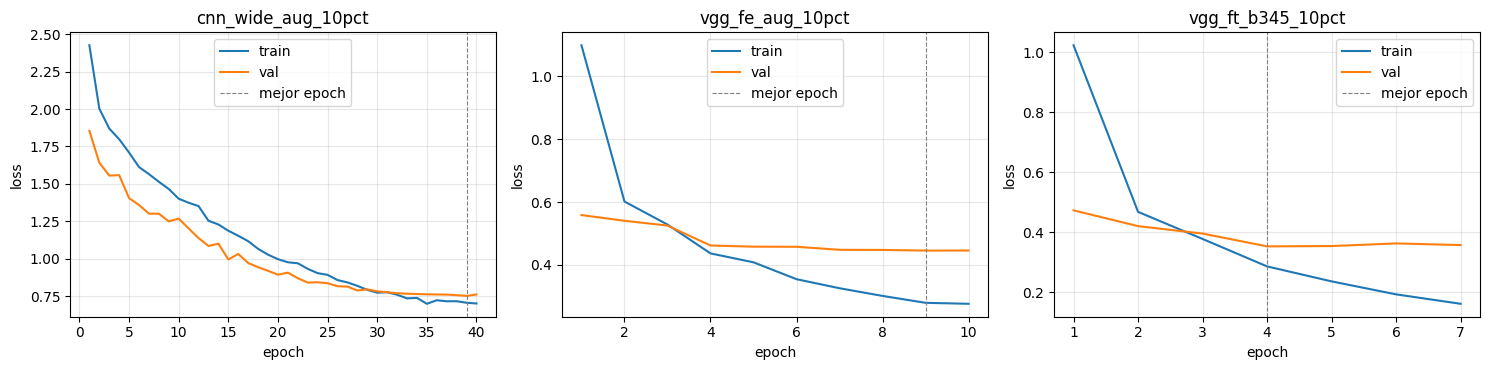

In [29]:
small_results = {}
for label, name in BEST_SMALL.items():
    model = load_trained_model(name)
    _, y_pred, y_true = evaluate(model, DATA[runs[name]["cfg"]["family"]]["test_loader"], nn.CrossEntropyLoss())
    small_results[label] = compute_metrics(y_true, y_pred)
    del model

rows = []
for label in BEST:
    full, small = test_results[label], small_results[label]
    rows.append({"modelo": label,
                 "acc 100%": full["accuracy"], f"acc {int(FRACTION*100)}%": small["accuracy"],
                 "F1 100%": full["f1_macro"], f"F1 {int(FRACTION*100)}%": small["f1_macro"],
                 "caída F1 (pts)": 100 * (full["f1_macro"] - small["f1_macro"]),
                 "caída F1 relativa (%)": 100 * (full["f1_macro"] - small["f1_macro"]) / full["f1_macro"],
                 "tiempo total 100% (s)": runs[BEST[label]]["total_time"],
                 f"tiempo total {int(FRACTION*100)}% (s)": runs[BEST_SMALL[label]]["total_time"]})
data_fraction_df = pd.DataFrame(rows).set_index("modelo")
display(data_fraction_df.round(4))

plot_curves(list(BEST_SMALL.values()))

**Discusión** *(completar)*: ¿qué modelo se degrada más al reducir los datos? Con menos datos se espera una brecha train-val mayor. Una CNN entrenada desde cero suele degradarse más que un modelo preentrenado.

## 9. Comparación de rendimiento y recursos
Para la mejor configuración de cada modelo se mide:
- **Parámetros** totales y entrenables.
- **MACs por imagen** (forward) con `torchinfo`. **FLOPs ≈ 2 × MACs**, porque cada multiply-accumulate es una multiplicación y una suma.
- **Latencia de inferencia en GPU**: tiempo promedio por imagen con batch 1, y también por imagen con batch 128 (throughput). Se usa `torch.cuda.synchronize()` antes de tomar cada tiempo.
- **Costo de entrenamiento:** tiempo por epoch, epoch con la mejor métrica de validación, tiempo total y memoria pico (`torch.cuda.max_memory_allocated()`).
- **Cómputo total de entrenamiento (FLOPs).** Por imagen, el forward cuesta `F` y el backward ≈ `2 × F_bwd`, donde `F_bwd` son los MACs de las capas por las que pasa el backward. Esas capas van desde la primera capa entrenable hasta la salida; las capas congeladas anteriores no hacen backward. Entonces:
  `FLOPs_train ≈ 2 · N_imágenes · epochs · (F + 2·F_bwd)`.
  Solo se cuentan las imágenes de entrenamiento; los forward de validación son un costo adicional pequeño.

In [30]:
def macs_breakdown(model, input_size):
    # MACs por imagen (forward) con torchinfo, y MACs de la parte de la red que hace backward
    # (desde la primera capa con parámetros entrenables hasta la salida)
    stats = summary(model, input_size=input_size, verbose=0, device=device)
    leaves = [l for l in stats.summary_list if l.is_leaf_layer]
    first = next(i for i, l in enumerate(leaves) if any(p.requires_grad for p in l.module.parameters()))
    return stats.total_mult_adds, sum(l.macs for l in leaves[first:])

@torch.no_grad()
def measure_latency(model, input_size, batch_size=1, n_warmup=20, n_iter=100):
    # Tiempo promedio de inferencia por imagen (ms), en fp32
    model.eval()
    x = torch.randn(batch_size, *input_size[1:], device=device)
    for _ in range(n_warmup):
        model(x)
    if device.type == "cuda": torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(n_iter):
        model(x)
    if device.type == "cuda": torch.cuda.synchronize()
    return (time.perf_counter() - t0) / (n_iter * batch_size) * 1000

resources = {}
for label, name in BEST.items():
    r = runs[name]
    res = 32 if r["cfg"]["family"] == "cnn" else r["cfg"]["res"]
    input_size = (1, 3, res, res)
    model = load_trained_model(name)
    fwd_macs, bwd_macs = macs_breakdown(model, input_size)
    train_flops_per_img = 2 * (fwd_macs + 2 * bwd_macs)
    resources[label] = {
        "iteración": name,
        "resolución": f"{res}x{res}",
        "params totales": r["total_params"],
        "params entrenables": r["trainable_params"],
        "GMACs/img": fwd_macs / 1e9,
        "GFLOPs/img (inferencia)": 2 * fwd_macs / 1e9,
        "latencia bs=1 (ms/img)": measure_latency(model, input_size, batch_size=1),
        "latencia bs=128 (ms/img)": measure_latency(model, input_size, batch_size=128, n_iter=20),
        "s/epoch": r["mean_epoch_time"],
        "mejor epoch": r["best_epoch"],
        "epochs corridos": r["epochs_run"],
        "tiempo total (s)": r["total_time"],
        "tiempo hasta mejor epoch (s)": float(np.sum(r["history"]["epoch_time"][:r["best_epoch"]])),
        "mem pico GPU (MB)": r["peak_mem_mb"],
        "GFLOPs train/img": train_flops_per_img / 1e9,
        "PFLOPs train (total)": train_flops_per_img * r["n_train"] * r["epochs_run"] / 1e15,
        "PFLOPs train (hasta mejor epoch)": train_flops_per_img * r["n_train"] * r["best_epoch"] / 1e15,
    }
    del model
if device.type == "cuda": torch.cuda.empty_cache()

resources_df = pd.DataFrame(resources).T
test_part = test_df[["accuracy", "precision_macro", "recall_macro", "f1_macro"]].add_prefix("test ")
small_part = data_fraction_df[[f"acc {int(FRACTION*100)}%", f"F1 {int(FRACTION*100)}%", "caída F1 (pts)"]].add_prefix("test ")
comparison_df = pd.concat([resources_df, test_part, small_part], axis=1)
display(comparison_df.T)

,CNN desde cero,VGG-16 feature extractor,VGG-16 fine-tuning
iteración,cnn_wide_aug,vgg_fe_aug,vgg_ft_b345
resolución,32x32,128x128,128x128
params totales,3250122,134301514,134301514
params entrenables,3250122,119586826,134041354
GMACs/img,0.15487,5.135155,5.135155
GFLOPs/img (inferencia),0.30974,10.27031,10.27031
latencia bs=1 (ms/img),1.253446,3.582982,3.630708
latencia bs=128 (ms/img),0.042306,1.328961,1.326354
s/epoch,8.089248,63.283071,98.652429
mejor epoch,37,10,9


### 9.1 Accuracy de validación vs tiempo de entrenamiento acumulado

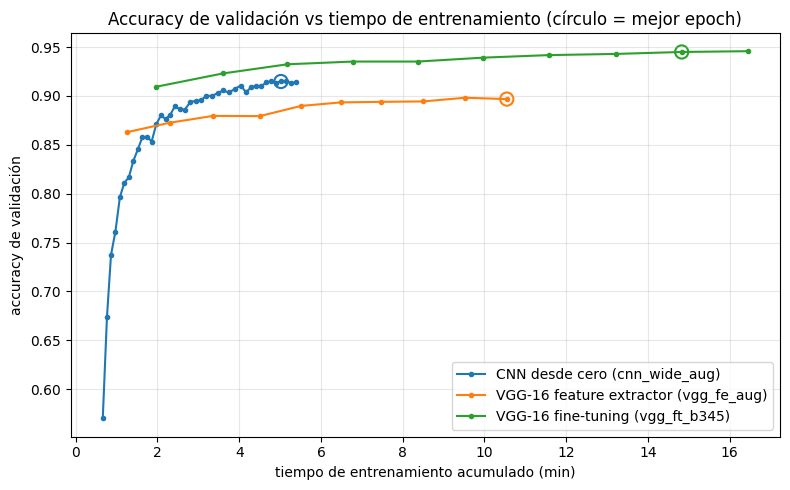

In [31]:
fig, ax = plt.subplots(figsize=(8, 5))
for label, name in BEST.items():
    h = runs[name]["history"]
    t = np.cumsum(h["epoch_time"]) / 60
    line, = ax.plot(t, h["val_acc"], marker="o", ms=3, label=f"{label} ({name})")
    b = runs[name]["best_epoch"] - 1
    ax.scatter(t[b], h["val_acc"][b], s=90, facecolors="none", edgecolors=line.get_color(), lw=1.5)
ax.set_xlabel("tiempo de entrenamiento acumulado (min)"); ax.set_ylabel("accuracy de validación")
ax.set_title("Accuracy de validación vs tiempo de entrenamiento (círculo = mejor epoch)")
ax.grid(alpha=.3); ax.legend()
plt.tight_layout(); plt.show()

### 9.2 F1-score de test vs costo computacional

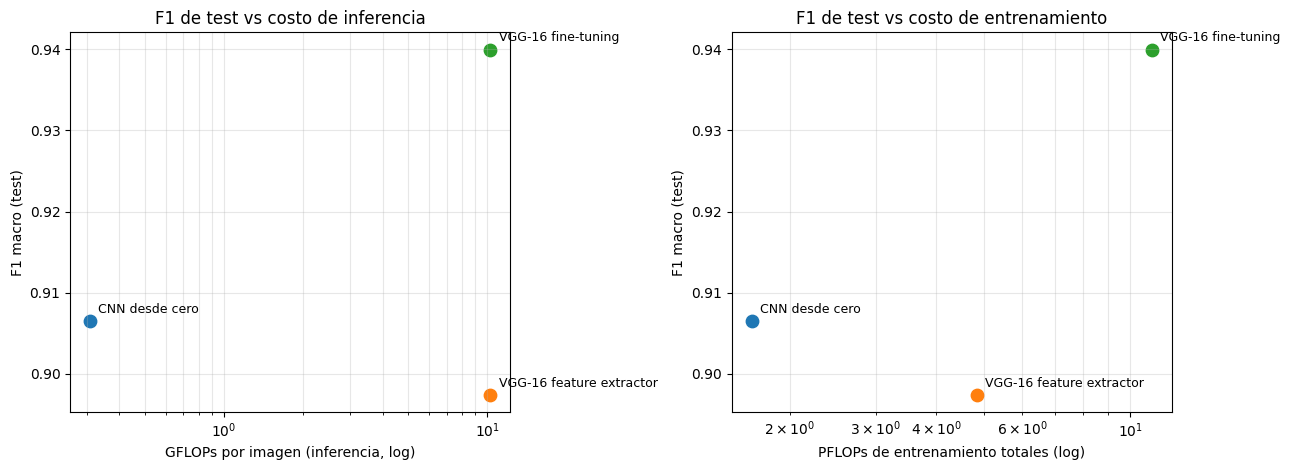

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, col, xlabel in [(axes[0], "GFLOPs/img (inferencia)", "GFLOPs por imagen (inferencia, log)"),
                        (axes[1], "PFLOPs train (total)", "PFLOPs de entrenamiento totales (log)")]:
    for label in BEST:
        x, y = comparison_df.loc[label, col], comparison_df.loc[label, "test f1_macro"]
        ax.scatter(x, y, s=80)
        ax.annotate(label, (x, y), textcoords="offset points", xytext=(6, 6), fontsize=9)
    ax.set_xscale("log"); ax.set_xlabel(xlabel); ax.set_ylabel("F1 macro (test)"); ax.grid(alpha=.3, which="both")
axes[0].set_title("F1 de test vs costo de inferencia"); axes[1].set_title("F1 de test vs costo de entrenamiento")
plt.tight_layout(); plt.show()

## 10. Guardado de resultados
Los modelos entrenados ya quedaron en `outputs/models/`. Aquí se guardan las tablas de resultados (para el reporte) y el split.

In [33]:
os.makedirs("outputs", exist_ok=True)
results_cnn.to_csv("outputs/iteraciones_cnn.csv")
results_fe.to_csv("outputs/iteraciones_vgg_fe.csv")
results_ft.to_csv("outputs/iteraciones_vgg_ft.csv")
test_df.to_csv("outputs/test_mejores_modelos.csv")
data_fraction_df.to_csv("outputs/experimento_cantidad_datos.csv")
comparison_df.to_csv("outputs/comparacion_recursos.csv")
np.save("outputs/split_train_idx.npy", train_idx); np.save("outputs/split_val_idx.npy", val_idx)
print("Guardado en ./outputs")

Guardado en ./outputs
